`Práctica Nº 7 - Aprendizaje Profundo`


# **CLASIFICACIÓN  DE TEXTO CON DIFERENTES MODELOS**

##*Dataset: Poem Sentiment*

## 00. Preparación general

In [1]:
!pip install -q fastai datasets evaluate transformers[sentencepiece] accelerate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score

# Carga del dataset
dataset = load_dataset('poem_sentiment')
dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/35.6k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/6.34k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/6.16k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/892 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/105 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/104 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'verse_text', 'label'],
        num_rows: 892
    })
    validation: Dataset({
        features: ['id', 'verse_text', 'label'],
        num_rows: 105
    })
    test: Dataset({
        features: ['id', 'verse_text', 'label'],
        num_rows: 104
    })
})

In [3]:
# Conversión a dataframes
train_df = dataset['train'].to_pandas().copy()
valid_df = dataset['validation'].to_pandas().copy()
test_df  = dataset['test'].to_pandas().copy()

print('Tamaño train:', len(train_df))
print('Tamaño validation:', len(valid_df))
print('Tamaño test:', len(test_df))

label_names = dataset['train'].features['label'].names
id2label = {i: label_names[i] for i in range(len(label_names))}
label2id = {v:k for k,v in id2label.items()}

print('Etiquetas:', label_names)
train_df.head()

Tamaño train: 892
Tamaño validation: 105
Tamaño test: 104
Etiquetas: ['negative', 'positive', 'no_impact', 'mixed']


,id,verse_text,label
0,0,with pale blue berries. in these peaceful shad...,1
1,1,"it flows so long as falls the rain,",2
2,2,"and that is why, the lonesome day,",0
3,3,"when i peruse the conquered fame of heroes, an...",3
4,4,of inward strife for truth and liberty.,3


# 01. Modelo de clasificación usando LSTM (FastAI)

In [4]:
from fastai.text.all import *

In [5]:
# Preparación de datos para FastAI
train_df_lstm = train_df.copy()
valid_df_lstm = valid_df.copy()

train_df_lstm['set'] = False
valid_df_lstm['set'] = True

train_df_lstm = train_df_lstm.drop(columns=['id'])
valid_df_lstm = valid_df_lstm.drop(columns=['id'])

train_valid_df_lstm = pd.concat([train_df_lstm, valid_df_lstm], ignore_index=True)
train_valid_df_lstm = train_valid_df_lstm.rename(columns={'verse_text': 'text'})
train_valid_df_lstm.head()

,text,label,set
0,with pale blue berries. in these peaceful shades--,1,False
1,"it flows so long as falls the rain,",2,False
2,"and that is why, the lonesome day,",0,False
3,"when i peruse the conquered fame of heroes, and the victories of mighty generals, i do not envy the generals,",3,False
4,of inward strife for truth and liberty.,3,False


In [6]:
sentiment_clas_lstm = DataBlock(
    blocks=(TextBlock.from_df('text'), CategoryBlock),
    get_x=ColReader('text'),
    get_y=ColReader('label'),
    splitter=ColSplitter('set')
)

dls_lstm = sentiment_clas_lstm.dataloaders(train_valid_df_lstm, bs=64)
dls_lstm.show_batch(max_n=2)

,text,category
0,"xxbos when i xxunk the xxunk xxunk of xxunk , and the xxunk of mighty xxunk , i do not envy the xxunk ,",3
1,"xxbos till , xxunk ' xxunk i know , there xxunk xxunk an xxunk xxunk i could lay my xxunk ' on ,",2


In [7]:
callbacks = [ShowGraphCallback(), SaveModelCallback()]

learn_lstm = text_classifier_learner(
    dls_lstm,
    AWD_LSTM,
    drop_mult=0.5,
    metrics=accuracy,
    cbs=callbacks
).to_fp16()

<div><progress max="105067061" value="105070592"></progress> 100.00% [105070592/105067061 00:02&lt;00:00]</div>

/usr/local/lib/python3.12/dist-packages/fastai/callback/fp16.py:47: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  self.autocast,self.learn.scaler,self.scales = autocast('cuda', dtype=dtype),GradScaler('cuda', **self.kwargs),L()
/usr/local/lib/python3.12/dist-packages/fastai/callback/fp16.py:47: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  self.autocast,self.learn.scaler,self.scales = autocast('cuda', dtype=dtype),GradScaler('cuda', **self.kwargs),L()


<div></div>

SuggestedLRs(valley=0.002511886414140463)

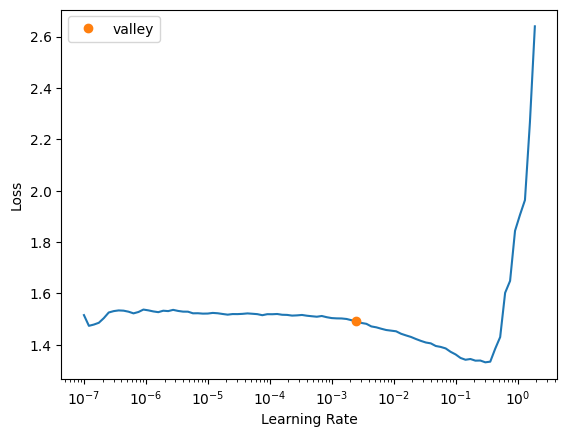

In [8]:
learn_lstm.lr_find()

/usr/local/lib/python3.12/dist-packages/fastai/callback/fp16.py:47: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  self.autocast,self.learn.scaler,self.scales = autocast('cuda', dtype=dtype),GradScaler('cuda', **self.kwargs),L()
/usr/local/lib/python3.12/dist-packages/fastai/callback/fp16.py:47: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  self.autocast,self.learn.scaler,self.scales = autocast('cuda', dtype=dtype),GradScaler('cuda', **self.kwargs),L()


epoch,train_loss,valid_loss,accuracy,time
0,1.444382,1.167034,0.676190,00:14


Better model found at epoch 0 with valid_loss value: 1.1670335531234741.


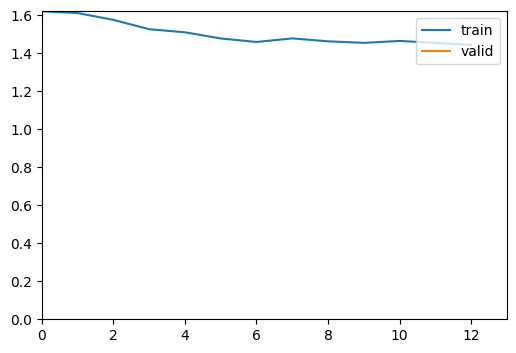

/usr/local/lib/python3.12/dist-packages/fastai/callback/fp16.py:47: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  self.autocast,self.learn.scaler,self.scales = autocast('cuda', dtype=dtype),GradScaler('cuda', **self.kwargs),L()
/usr/local/lib/python3.12/dist-packages/fastai/callback/fp16.py:47: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  self.autocast,self.learn.scaler,self.scales = autocast('cuda', dtype=dtype),GradScaler('cuda', **self.kwargs),L()


epoch,train_loss,valid_loss,accuracy,time
0,1.181430,1.057965,0.714286,00:33
1,1.109515,0.906782,0.695238,00:31
2,0.997501,0.967989,0.647619,00:34
3,0.906920,0.980471,0.638095,00:31
4,0.804868,1.068325,0.609524,00:30
5,0.686818,1.104338,0.638095,00:35
6,0.585405,1.094994,0.666667,00:33
7,0.488740,1.029162,0.638095,00:32
8,0.416685,1.039838,0.647619,00:31
9,0.355985,1.054453,0.628571,00:30


Better model found at epoch 0 with valid_loss value: 1.05796480178833.


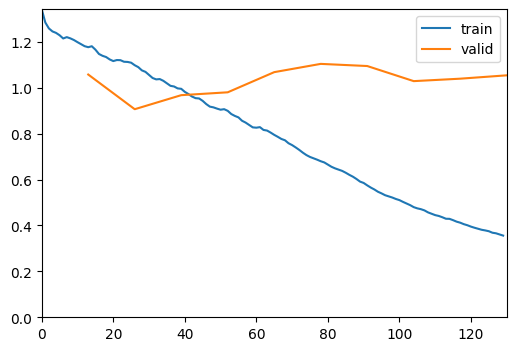

Better model found at epoch 1 with valid_loss value: 0.906781792640686.


In [9]:
learn_lstm.fine_tune(10, 2e-2)

In [10]:
# Evaluación en test del modelo LSTM
test_df_lstm = test_df.copy().drop(columns=['id']).rename(columns={'verse_text': 'text'})
dl_test_lstm = learn_lstm.dls.test_dl(test_df_lstm, with_labels=True)

lstm_loss = float(learn_lstm.validate(dl=dl_test_lstm)[0])
preds_lstm, targs_lstm = learn_lstm.get_preds(dl=dl_test_lstm)
y_pred_lstm = preds_lstm.argmax(dim=1).cpu().numpy()
y_true_lstm = targs_lstm.cpu().numpy()

lstm_test_metrics = {
    'Modelo': 'AWD_LSTM',
    'Test Loss': lstm_loss,
    'Accuracy': accuracy_score(y_true_lstm, y_pred_lstm),
    'F1 macro': f1_score(y_true_lstm, y_pred_lstm, average='macro')
}
lstm_test_metrics

/usr/local/lib/python3.12/dist-packages/fastai/callback/fp16.py:47: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  self.autocast,self.learn.scaler,self.scales = autocast('cuda', dtype=dtype),GradScaler('cuda', **self.kwargs),L()
/usr/local/lib/python3.12/dist-packages/fastai/callback/fp16.py:47: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  self.autocast,self.learn.scaler,self.scales = autocast('cuda', dtype=dtype),GradScaler('cuda', **self.kwargs),L()


Better model found at epoch 0 with valid_loss value: 0.6634615659713745.


/usr/local/lib/python3.12/dist-packages/fastai/callback/fp16.py:47: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  self.autocast,self.learn.scaler,self.scales = autocast('cuda', dtype=dtype),GradScaler('cuda', **self.kwargs),L()
/usr/local/lib/python3.12/dist-packages/fastai/callback/fp16.py:47: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  self.autocast,self.learn.scaler,self.scales = autocast('cuda', dtype=dtype),GradScaler('cuda', **self.kwargs),L()


{'Modelo': 'AWD_LSTM',
 'Test Loss': 0.976914644241333,
 'Accuracy': 0.6634615384615384,
 'F1 macro': 0.3602983362019507}

# 02. Modelo de lenguaje + clasificación (ULMFiT)

In [11]:
# Preparación de datos para ULMFiT
train_df_ulmfit = train_df.copy()
valid_df_ulmfit = valid_df.copy()

train_df_ulmfit['set'] = False
valid_df_ulmfit['set'] = True
train_df_ulmfit = train_df_ulmfit.drop(columns=['id'])
valid_df_ulmfit = valid_df_ulmfit.drop(columns=['id'])

train_valid_df_ulmfit = pd.concat([train_df_ulmfit, valid_df_ulmfit], ignore_index=True)
train_valid_df_ulmfit = train_valid_df_ulmfit.rename(columns={'verse_text': 'text'})
train_valid_df_ulmfit.head()

,text,label,set
0,with pale blue berries. in these peaceful shades--,1,False
1,"it flows so long as falls the rain,",2,False
2,"and that is why, the lonesome day,",0,False
3,"when i peruse the conquered fame of heroes, and the victories of mighty generals, i do not envy the generals,",3,False
4,of inward strife for truth and liberty.,3,False


In [12]:
# 1) Modelo de lenguaje
db_lm = DataBlock(
    blocks=TextBlock.from_df('text', is_lm=True, max_vocab=100000),
    get_items=ColReader('text'),
    splitter=RandomSplitter(0.1)
)

dls_lm = db_lm.dataloaders(train_valid_df_ulmfit, bs=128, seq_len=80)
dls_lm.show_batch(max_n=2)

xxbos beneath thy xxunk xxunk ! xxbos be xxunk to read it xxunk . so , i xxunk xxbos that you or xxunk , xxunk an xxunk , xxbos the xxunk xxunk xxunk his xxunk , xxbos or by some xxunk door , a xxunk xxbos xxunk xxunk , though xxunk and lonely , xxbos and leaves the world to xxunk and to me . xxbos who
xxunk this xxunk xxunk i xxunk xxbos and very xxunk of a xxunk . xxbos his xxunk xxunk a just xxunk xxunk . xxbos and she passed out xxunk the xxunk things , xxbos xxunk , land ! thou hast xxunk : ' tis done . xxbos the second xxunk sounds , the xxunk xxunk xxbos come up like ocean xxunk . but the xxunk xxbos as
beneath thy xxunk xxunk ! xxbos be xxunk to read it xxunk . so , i xxunk xxbos that you or xxunk , xxunk an xxunk , xxbos the xxunk xxunk xxunk his xxunk , xxbos or by some xxunk door , a xxunk xxbos xxunk xxunk , though xxunk and lonely , xxbos and leaves the world to xxunk and to me . xxbos who xxunk
this xxunk xxunk i xxunk xxbos and very xxunk of a xxunk . xxbos his xxunk xxu

In [13]:
learn_lm = language_model_learner(
    dls_lm,
    AWD_LSTM,
    drop_mult=0.3,
    metrics=[accuracy, Perplexity()]
).to_fp16()

In [14]:
learn_lm.fine_tune(10, base_lr=2e-2)

/usr/local/lib/python3.12/dist-packages/fastai/callback/fp16.py:47: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  self.autocast,self.learn.scaler,self.scales = autocast('cuda', dtype=dtype),GradScaler('cuda', **self.kwargs),L()
/usr/local/lib/python3.12/dist-packages/fastai/callback/fp16.py:47: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  self.autocast,self.learn.scaler,self.scales = autocast('cuda', dtype=dtype),GradScaler('cuda', **self.kwargs),L()


epoch,train_loss,valid_loss,accuracy,perplexity,time
0,5.308422,5.343958,0.080357,209.339722,00:24


/usr/local/lib/python3.12/dist-packages/fastai/callback/fp16.py:47: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  self.autocast,self.learn.scaler,self.scales = autocast('cuda', dtype=dtype),GradScaler('cuda', **self.kwargs),L()
/usr/local/lib/python3.12/dist-packages/fastai/callback/fp16.py:47: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  self.autocast,self.learn.scaler,self.scales = autocast('cuda', dtype=dtype),GradScaler('cuda', **self.kwargs),L()


epoch,train_loss,valid_loss,accuracy,perplexity,time
0,5.257397,5.002099,0.130580,148.725006,00:21
1,5.033715,4.571516,0.207589,96.690536,00:21
2,4.767299,4.170180,0.227679,64.727089,00:25
3,4.612590,4.077729,0.261161,59.011288,00:23
4,4.440083,3.977106,0.260045,53.362373,00:21
5,4.305058,3.851887,0.261161,47.081821,00:22
6,4.184761,3.744648,0.276786,42.294136,00:22
7,4.081434,3.678539,0.285714,39.588516,00:21
8,3.992852,3.650687,0.293527,38.501106,00:22
9,3.920441,3.644171,0.293527,38.251049,00:22


In [15]:
learn_lm.save_encoder('finetuned_ulmfit')

In [16]:
# 2) Clasificador inicializado con el encoder ajustado
sentiment_clas_ulmfit = DataBlock(
    blocks=(TextBlock.from_df('text', vocab=dls_lm.vocab), CategoryBlock),
    get_x=ColReader('text'),
    get_y=ColReader('label'),
    splitter=ColSplitter('set')
)

dls_ulmfit = sentiment_clas_ulmfit.dataloaders(train_valid_df_ulmfit, bs=64)
dls_ulmfit.show_batch(max_n=2)

,text,category
0,"xxbos when i xxunk the xxunk xxunk of xxunk , and the xxunk of mighty xxunk , i do not envy the xxunk ,",3
1,"xxbos till , xxunk ' xxunk i know , there xxunk xxunk an xxunk xxunk i could lay my xxunk ' on ,",2


In [17]:
callbacks = [ShowGraphCallback(), SaveModelCallback()]

learn_ulmfit = text_classifier_learner(
    dls_ulmfit,
    AWD_LSTM,
    drop_mult=0.5,
    metrics=accuracy,
    cbs=callbacks
).to_fp16()

learn_ulmfit = learn_ulmfit.load_encoder('finetuned_ulmfit')

/usr/local/lib/python3.12/dist-packages/fastai/callback/fp16.py:47: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  self.autocast,self.learn.scaler,self.scales = autocast('cuda', dtype=dtype),GradScaler('cuda', **self.kwargs),L()
/usr/local/lib/python3.12/dist-packages/fastai/callback/fp16.py:47: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  self.autocast,self.learn.scaler,self.scales = autocast('cuda', dtype=dtype),GradScaler('cuda', **self.kwargs),L()


<div></div>

SuggestedLRs(valley=0.007585775572806597)

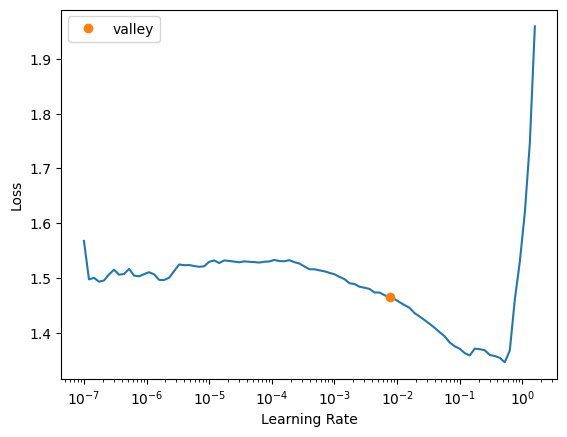

In [18]:
learn_ulmfit.lr_find()

/usr/local/lib/python3.12/dist-packages/fastai/callback/fp16.py:47: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  self.autocast,self.learn.scaler,self.scales = autocast('cuda', dtype=dtype),GradScaler('cuda', **self.kwargs),L()
/usr/local/lib/python3.12/dist-packages/fastai/callback/fp16.py:47: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  self.autocast,self.learn.scaler,self.scales = autocast('cuda', dtype=dtype),GradScaler('cuda', **self.kwargs),L()


epoch,train_loss,valid_loss,accuracy,time
0,1.377734,0.964205,0.647619,00:14


Better model found at epoch 0 with valid_loss value: 0.9642047882080078.


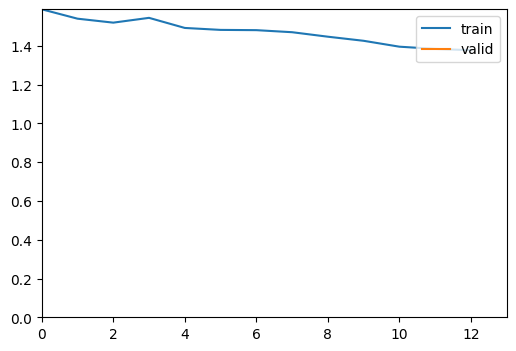

/usr/local/lib/python3.12/dist-packages/fastai/callback/fp16.py:47: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  self.autocast,self.learn.scaler,self.scales = autocast('cuda', dtype=dtype),GradScaler('cuda', **self.kwargs),L()
/usr/local/lib/python3.12/dist-packages/fastai/callback/fp16.py:47: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  self.autocast,self.learn.scaler,self.scales = autocast('cuda', dtype=dtype),GradScaler('cuda', **self.kwargs),L()


epoch,train_loss,valid_loss,accuracy,time
0,1.048223,0.936648,0.657143,00:33
1,0.957437,0.935171,0.638095,00:31
2,0.905075,1.130798,0.657143,00:32
3,0.835853,1.007228,0.685714,00:36
4,0.750363,1.001113,0.666667,00:32
5,0.647323,1.382710,0.647619,00:32
6,0.547021,1.606265,0.571429,00:43
7,0.452912,1.385399,0.628571,00:40
8,0.368440,1.413264,0.628571,00:31
9,0.320592,1.390327,0.619048,00:32


Better model found at epoch 0 with valid_loss value: 0.9366481304168701.


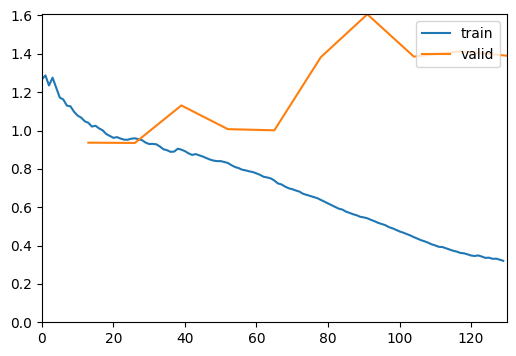

Better model found at epoch 1 with valid_loss value: 0.935171365737915.


In [19]:
learn_ulmfit.fine_tune(10, 6e-2)

In [20]:
# Evaluación en test del modelo ULMFiT
test_df_ulmfit = test_df.copy().drop(columns=['id']).rename(columns={'verse_text': 'text'})
dl_test_ulmfit = learn_ulmfit.dls.test_dl(test_df_ulmfit, with_labels=True)

ulmfit_loss = float(learn_ulmfit.validate(dl=dl_test_ulmfit)[0])
preds_ulmfit, targs_ulmfit = learn_ulmfit.get_preds(dl=dl_test_ulmfit)
y_pred_ulmfit = preds_ulmfit.argmax(dim=1).cpu().numpy()
y_true_ulmfit = targs_ulmfit.cpu().numpy()

ulmfit_test_metrics = {
    'Modelo': 'ULMFiT (AWD_LSTM + LM)',
    'Test Loss': ulmfit_loss,
    'Accuracy': accuracy_score(y_true_ulmfit, y_pred_ulmfit),
    'F1 macro': f1_score(y_true_ulmfit, y_pred_ulmfit, average='macro')
}
ulmfit_test_metrics

/usr/local/lib/python3.12/dist-packages/fastai/callback/fp16.py:47: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  self.autocast,self.learn.scaler,self.scales = autocast('cuda', dtype=dtype),GradScaler('cuda', **self.kwargs),L()
/usr/local/lib/python3.12/dist-packages/fastai/callback/fp16.py:47: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  self.autocast,self.learn.scaler,self.scales = autocast('cuda', dtype=dtype),GradScaler('cuda', **self.kwargs),L()


Better model found at epoch 0 with valid_loss value: 0.6057692170143127.


/usr/local/lib/python3.12/dist-packages/fastai/callback/fp16.py:47: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  self.autocast,self.learn.scaler,self.scales = autocast('cuda', dtype=dtype),GradScaler('cuda', **self.kwargs),L()
/usr/local/lib/python3.12/dist-packages/fastai/callback/fp16.py:47: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  self.autocast,self.learn.scaler,self.scales = autocast('cuda', dtype=dtype),GradScaler('cuda', **self.kwargs),L()


{'Modelo': 'ULMFiT (AWD_LSTM + LM)',
 'Test Loss': 1.0637471675872803,
 'Accuracy': 0.6057692307692307,
 'F1 macro': 0.283778552071235}

# 03. Modelo basado en mecanismos de atención (BERT / Transformers)

In [21]:
from transformers import AutoTokenizer, DataCollatorWithPadding
from transformers import TrainingArguments, AutoModelForSequenceClassification, Trainer
import evaluate

In [22]:
model_checkpoint = 'bert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_function(batch):
    return tokenizer(batch['verse_text'], truncation=True)

tokenized_dataset = dataset.map(tokenize_function, batched=True)
tokenized_dataset

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/892 [00:00<?, ? examples/s]

Map:   0%|          | 0/105 [00:00<?, ? examples/s]

Map:   0%|          | 0/104 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'verse_text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 892
    })
    validation: Dataset({
        features: ['id', 'verse_text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 105
    })
    test: Dataset({
        features: ['id', 'verse_text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 104
    })
})

In [23]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
accuracy_metric = evaluate.load('accuracy')
f1_metric = evaluate.load('f1')

def compute_metrics(eval_preds):
    logits, labels = eval_preds
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels, average='macro')
    return {'accuracy': acc['accuracy'], 'f1_macro': f1['f1']}

In [25]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=4,
    id2label=id2label,
    label2id=label2id
)

training_args = TrainingArguments(
    output_dir='clasificador-poem-sentiment',
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    report_to='none'
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['validation'],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [26]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,No log,0.851821,0.657143,0.265896
2,No log,0.640150,0.800000,0.677507
3,No log,0.579855,0.838095,0.756110


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=168, training_loss=0.8034608023507255, metrics={'train_runtime': 667.4986, 'train_samples_per_second': 4.009, 'train_steps_per_second': 0.252, 'total_flos': 26399968466976.0, 'train_loss': 0.8034608023507255, 'epoch': 3.0})

In [27]:
val_results = trainer.evaluate(tokenized_dataset['validation'])
val_results

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 0.5798551440238953,
 'eval_accuracy': 0.8380952380952381,
 'eval_f1_macro': 0.7561098513479466,
 'eval_runtime': 5.7899,
 'eval_samples_per_second': 18.135,
 'eval_steps_per_second': 1.209,
 'epoch': 3.0}

In [28]:
test_results = trainer.evaluate(tokenized_dataset['test'])

bert_test_metrics = {
    'Modelo': 'BERT-base-uncased',
    'Test Loss': float(test_results['eval_loss']),
    'Accuracy': float(test_results['eval_accuracy']),
    'F1 macro': float(test_results['eval_f1_macro'])
}
bert_test_metrics

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'Modelo': 'BERT-base-uncased',
 'Test Loss': 0.5916835069656372,
 'Accuracy': 0.8461538461538461,
 'F1 macro': 0.7821262558104664}

# 04. Tabla comparativa final en test

In [29]:
comparison_df = pd.DataFrame([
    lstm_test_metrics,
    ulmfit_test_metrics,
    bert_test_metrics
])
comparison_df = comparison_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
comparison_df

,Modelo,Test Loss,Accuracy,F1 macro
0,BERT-base-uncased,0.591684,0.846154,0.782126
1,AWD_LSTM,0.976915,0.663462,0.360298
2,ULMFiT (AWD_LSTM + LM),1.063747,0.605769,0.283779


In [30]:
# Guardado opcional de resultados
comparison_df.to_csv('comparacion_modelos_poem_sentiment.csv', index=False)
print('Archivo guardado: comparacion_modelos_poem_sentiment.csv')

Archivo guardado: comparacion_modelos_poem_sentiment.csv
